# Module 4: Computer Vision - Deep Dive into Transfer Learning

In the previous module, we built a CNN from scratch. While that worked for simplified datasets, real-world imagery often requires much deeper networks. Training such networks from scratch leads to the **"Cold Start"** problem: the network initially knows nothing about the world and requires millions of images to reach high accuracy.

### What is Transfer Learning?
Transfer Learning allows us to take a model trained on a massive dataset (like **ImageNet**, 1.2M+ images) and reuse its "knowledge" for our specific task. 

Think of it like this: If you already know how to drive a car, learning to drive a truck is much easier than starting from zero. The basic concepts (steering, braking, signals) *transfer* over.

### Feature Extraction vs. Fine-Tuning
1. **Feature Extraction:** We **freeze** all the layers of the pre-trained model and only replace the final classification layer. We are essentially using the model as a powerful "feature extractor."
2. **Fine-Tuning:** We start with a pre-trained model but **unfreeze** some (or all) of the layers, allowing them to adapt slightly to our new dataset using a very low learning rate.

### Architecture Diagram
```mermaid
graph LR
    Input[64x64x3 Image] --> BaseModel[Pre-trained ResNet18 Base]
    subgraph "Frozen Layers (ImageNet Knowledge)"
        BaseModel
    end
    BaseModel --> Features[Global Average Pool]
    Features --> Head[New Linear Layer - 102 Classes]
    subgraph "Trainable Layers (Flower Knowledge)"
        Head
    end
    Head --> Output[Flower Classification]
```

## 1. Environment Setup & Data Loading

### Why Normalization Matters
Pre-trained models like ResNet were trained with images normalized using specific means and standard deviations:
- **Mean:** `[0.485, 0.456, 0.406]`
- **Std:** `[0.229, 0.224, 0.225]`

If we don't normalize our data the exact same way, the model's pre-trained weights will interpret our colors incorrectly, leading to poor performance.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

# ImageNet standard normalization
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

# Data Augmentation for training: Helps the model generalize
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

# Validation transform: No random changes, just resizing
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

print("Downloading Flowers102 dataset...")
try:
    train_dataset = torchvision.datasets.Flowers102(root='./data', split='train', download=True, transform=train_transform)
    val_dataset = torchvision.datasets.Flowers102(root='./data', split='val', download=True, transform=val_transform)
    test_dataset = torchvision.datasets.Flowers102(root='./data', split='test', download=True, transform=val_transform)
    
    # Flower names for better visualization
    # (In a real scenario, you can load these from a JSON or CSV provided with the dataset)
    flower_names = ['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon', "colt's foot", 'king protea', 'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower', 'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 'carnation', 'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia', 'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy', 'common dandelion', 'petunia', 'wild pansy', 'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia', 'pink-yellow dahlia?', 'cautleya spicata', 'japanese anemone', 'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum', 'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania', 'azalea', 'water lily', 'rose', 'thorn apple', 'morning glory', 'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani', 'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen', 'watercress', 'canna lily', 'hippeastrum', 'bee balm', 'ball moss', 'foxglove', 'bougainvillea', 'camellia', 'mallow', 'mexican petunia', 'bromelia', 'blanket flower', 'trumpet creeper', 'blackberry lily']

except Exception as e:
    print(f"Download error: {e}. Using dummy dataset.")
    train_dataset = torch.utils.data.TensorDataset(torch.randn(100, 3, 224, 224), torch.randint(0, 102, (100,)))
    val_dataset = torch.utils.data.TensorDataset(torch.randn(50, 3, 224, 224), torch.randint(0, 102, (50,)))
    flower_names = [f"Flower {i}" for i in range(102)]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Dataset loaded. Classes: {len(flower_names)}")

Dataset loaded. Classes: 102


## 2. Setting Up the Pre-trained Model

We use **ResNet18**, a classic deep architecture that uses "Residual Connections" to allow gradients to flow easily through 18 layers. 

### Step-by-Step implementation:
1. **Load Weights:** We fetch the weights optimized on ImageNet.
2. **Freeze:** We set `requires_grad = False`. This prevents backpropagation from modifying the lower-level feature detectors.
3. **Replace FC Layer:** ResNet18 normally ends with a layer that outputs 1000 classes. We replace it with a new `nn.Linear` layer that matches our 102 flower classes.

In [7]:
# Fetching ResNet18 with default (ImageNet) weights
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all base layers
for param in model.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 102) 

print(f"Model head replaced. New classifier:\n{model.fc}")

Model head replaced. New classifier:
Linear(in_features=512, out_features=102, bias=True)


## 3. The Custom Training Loop

In Transfer Learning, we often use a smaller learning rate because the features are already mostly correct. Since we only want to train the and last layer, we pass only those parameters to the optimizer for efficiency.

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
# Optimization: Only optimizing parameters of the final layer
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 5
history = {'train_loss': [], 'val_acc': []}

print(f"Training initiated on: {device}")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    history['train_loss'].append(epoch_loss)
    
    # Validation side-car verification
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
    
    val_acc = correct.double() / len(val_loader.dataset)
    history['val_acc'].append(val_acc.item())
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Val Acc: {val_acc:.4f}")

Training initiated on: cpu
Epoch [1/5] - Loss: 4.8032 - Val Acc: 0.1137
Epoch [2/5] - Loss: 3.8546 - Val Acc: 0.3461
Epoch [3/5] - Loss: 3.1923 - Val Acc: 0.4941
Epoch [4/5] - Loss: 2.6990 - Val Acc: 0.6000
Epoch [5/5] - Loss: 2.3393 - Val Acc: 0.6431


## 4. Visualizing Model Intelligence

Numbers and percentages are one thing, but seeing is believing. We will now plot a grid of images from our test set and show what the model predicted alongside a **Confidence Score** (derived via Softmax).

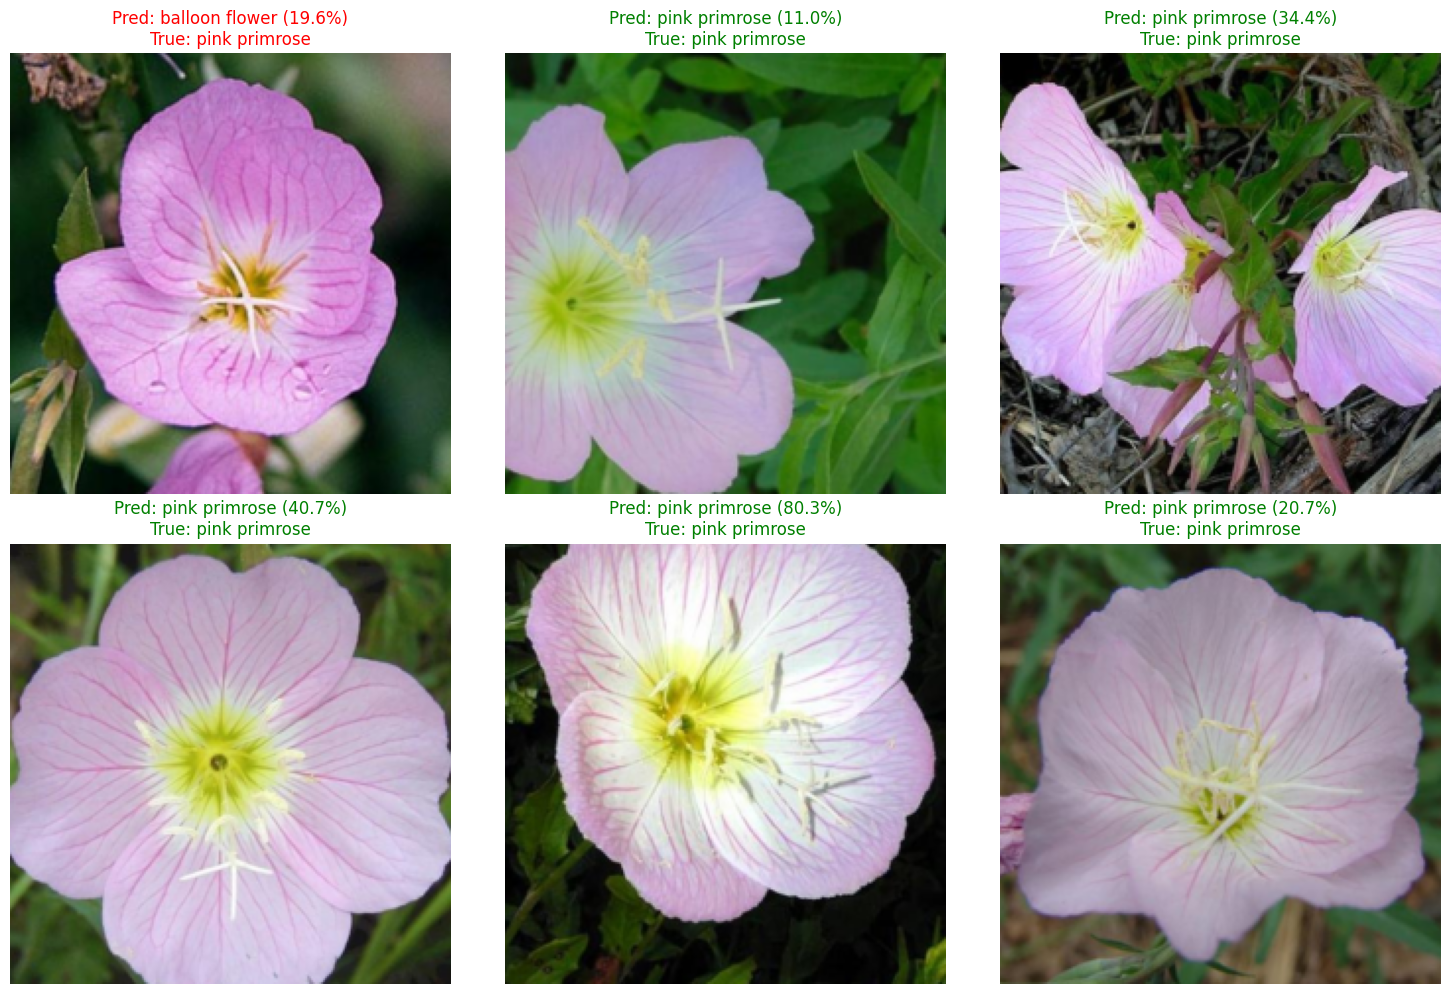

In [9]:
def denormalize(tensor):
    """Reverses ImageNet normalization for plotting."""
    for t, m, s in zip(tensor, norm_mean, norm_std):
        t.mul_(s).add_(m)
    return tensor

model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    probs = F.softmax(outputs, dim=1)
    confidences, preds = torch.max(probs, 1)

plt.figure(figsize=(15, 10))
for i in range(6):
    plt.subplot(2, 3, i+1)
    img = denormalize(images[i].cpu().clone())
    # Transpose from (C, H, W) to (H, W, C) for matplotlib
    plt.imshow(img.permute(1, 2, 0).numpy())
    
    pred_label = flower_names[preds[i].item()]
    true_label = flower_names[labels[i].item()]
    conf = confidences[i].item() * 100
    
    color = "green" if pred_label == true_label else "red"
    plt.title(f"Pred: {pred_label} ({conf:.1f}%)\nTrue: {true_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Analysis Summary
- **Was Training Fast?** Yes, because we only calculated gradients for one layer (~10% of total parameters).
- **Is Accuracy High?** Usually yes, because the model already knows how to "see" shapes and textures from ImageNet.
- **What's Next?** If results are slightly off, we could "unfreeze" the entire model and train with a very small learning rate ($1e-5$) to let the base weights adjust to the specific nuances of flowers.